In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import warnings

warnings.filterwarnings('ignore') # Agar tampilan lebih bersih dari peringatan teknis
sns.set(style="whitegrid")


df = pd.read_csv('marketing_data.csv')
df.columns = df.columns.str.strip() # Bersihkan spasi di nama kolom

In [2]:
#Q1: Apakah ada features yang data type-nya tidak sesuai?
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ID                   2240 non-null   int64 
 1   Year_Birth           2240 non-null   int64 
 2   Education            2240 non-null   object
 3   Marital_Status       2240 non-null   object
 4   Income               2216 non-null   object
 5   Kidhome              2240 non-null   int64 
 6   Teenhome             2240 non-null   int64 
 7   Dt_Customer          2240 non-null   object
 8   Recency              2240 non-null   int64 
 9   MntWines             2240 non-null   int64 
 10  MntFruits            2240 non-null   int64 
 11  MntMeatProducts      2240 non-null   int64 
 12  MntFishProducts      2240 non-null   int64 
 13  MntSweetProducts     2240 non-null   int64 
 14  MntGoldProds         2240 non-null   int64 
 15  NumDealsPurchases    2240 non-null   int64 
 16  NumWeb

Income    24
dtype: int64

Jumlah Data Duplikat: 0


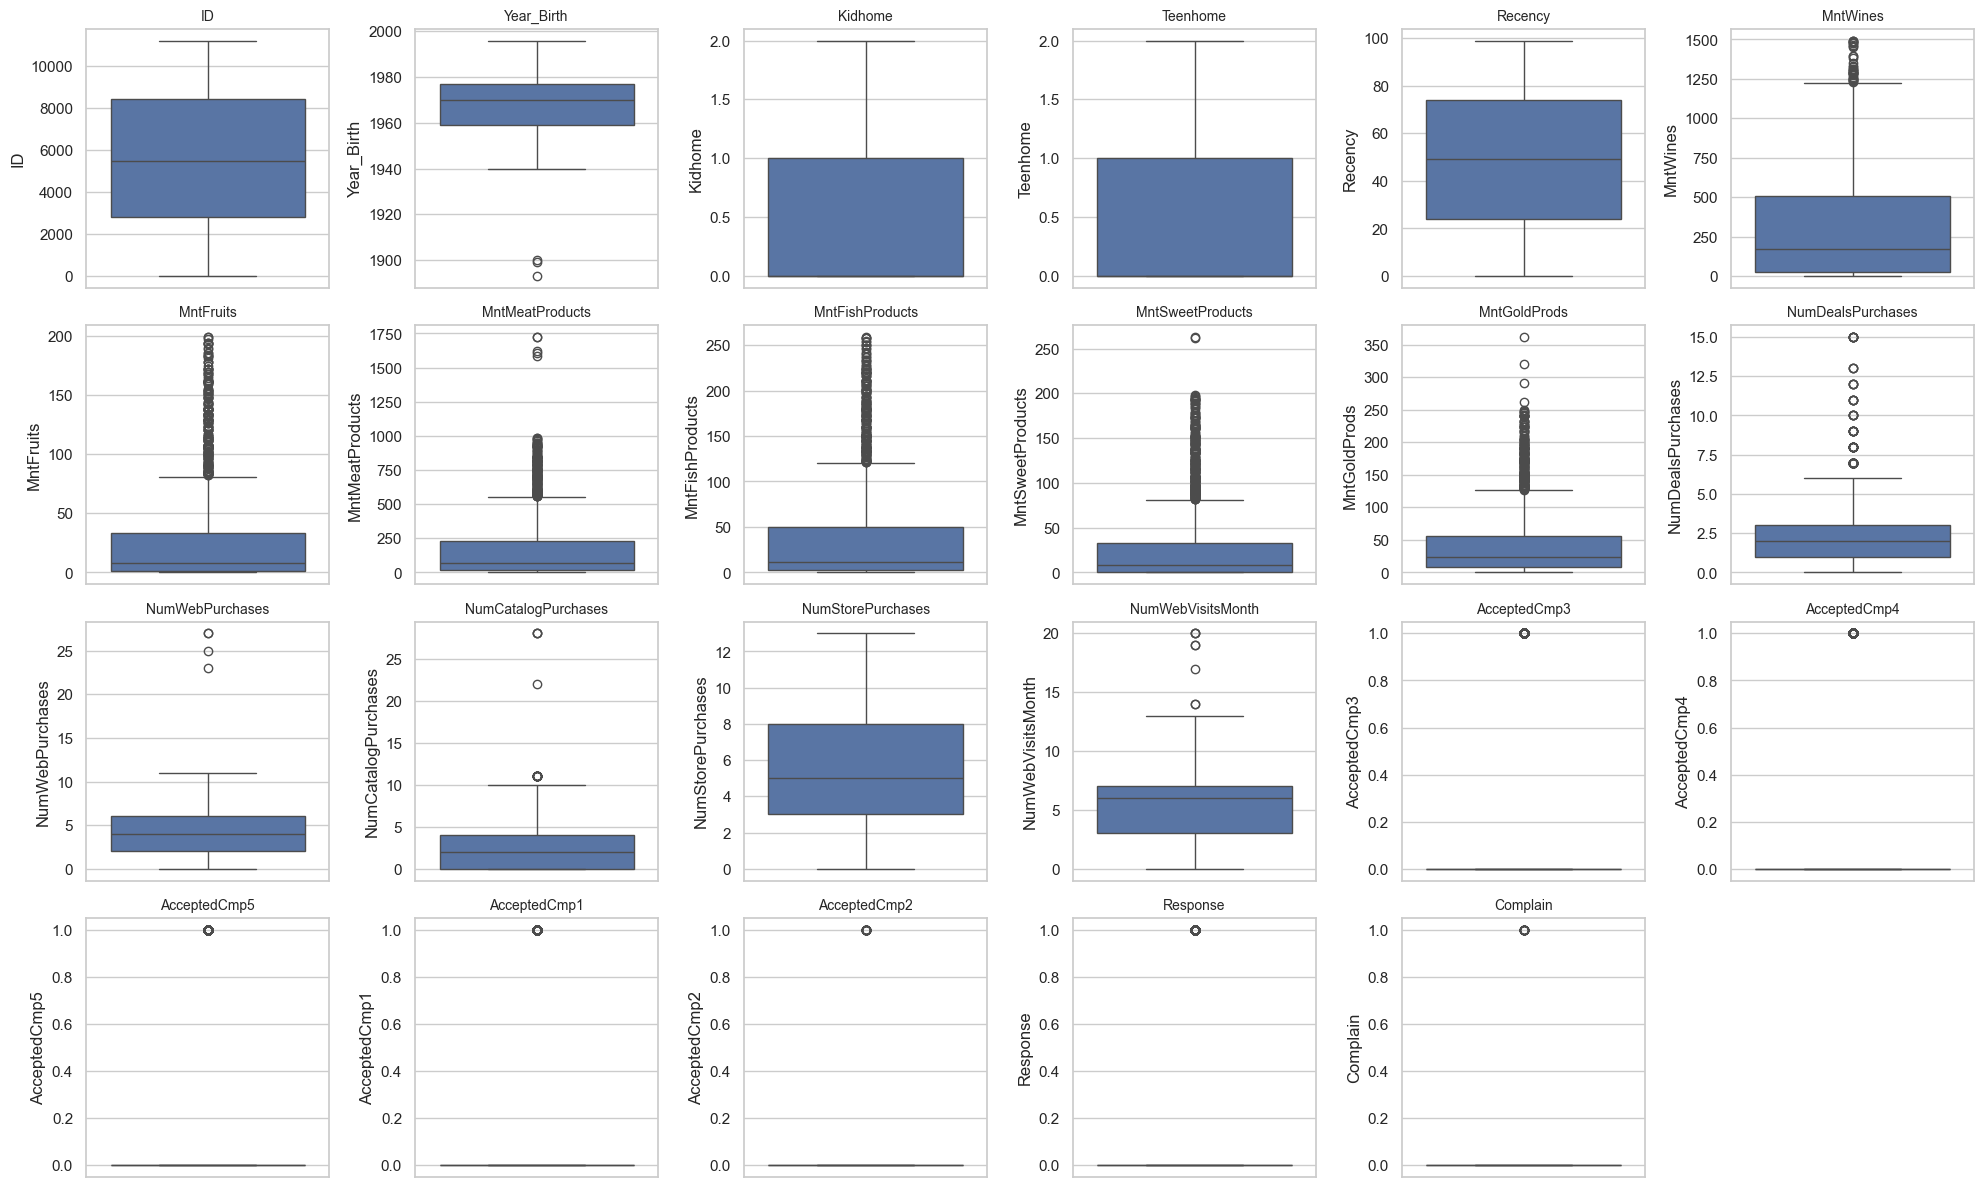

In [6]:
# 1. Check Missing Values
print(df.isnull().sum()[df.isnull().sum() > 0])

# 2. Check Duplicates
print(f"\nJumlah Data Duplikat: {df.duplicated().sum()}")

# 3. Cek Distribusi Tidak Masuk Akal (Outlier)
# Ambil semua kolom yang isinya angka
kolom_angka = df.select_dtypes(include=['int64', 'float64']).columns

# Buat grafik  untuk semua kolom angka tersebut
plt.figure(figsize=(20, 15))
for i, col in enumerate(kolom_angka):
    plt.subplot(5, 6, i+1) # Kita buat kotak-kotak kecil
    sns.boxplot(y=df[col])
    plt.title(col, fontsize=10)

plt.tight_layout()
plt.show()


In [ ]:
# Memperbaiki Tipe Data (Data Transformation)
# 1. Bersihkan dulu nama kolom dari spasi (sangat penting!)
df.columns = df.columns.str.strip()

# 2. Cek apakah kolom Income masih berupa teks. Jika iya, bersihkan.
if df['Income'].dtype == 'object':
    df['Income'] = df['Income'].str.replace('$', '', regex=False).str.replace(',', '', regex=False)
    df['Income'] = pd.to_numeric(df['Income'], errors='coerce')

# 3. Mengubah tipe data Dt_Customer menjadi tanggal
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'])

print("Langkah 1 Berhasil: Nama kolom dirapikan, Income & Tanggal sudah benar.")
# Cek tipe data sekarang
print(df[['Income', 'Dt_Customer']].dtypes)

Langkah 1 Berhasil: Nama kolom dirapikan, Income & Tanggal sudah benar.
Income                float64
Dt_Customer    datetime64[ns]
dtype: object


In [18]:
#Menangani Data Kosong (Missing Values)
# Mengisi data Income yang kosong dengan nilai Median
median_income = df['Income'].median()
df['Income'].fillna(median_income, inplace=True)

print(f"Langkah 2 Selesai: 24 data kosong sudah diisi dengan nilai median {median_income}.")

Langkah 2 Selesai: 24 data kosong sudah diisi dengan nilai median 51381.5.


In [19]:
#Eksekusi Pembuangan Outlier (Filtering
# 1. Hitung umur dulu
df['Age'] = 2014 - df['Year_Birth']

# 2. Filter: Hanya ambil yang umur < 90 DAN income < 200.000
df_clean = df[(df['Age'] < 90) & (df['Income'] < 200000)].copy()

print("Langkah 3 Selesai: Outlier ekstrem sudah dibuang.")
print(f"Data sekarang tersisa {len(df_clean)} baris dari total awal {len(df)} baris.")


Langkah 3 Selesai: Outlier ekstrem sudah dibuang.
Data sekarang tersisa 2236 baris dari total awal 2240 baris.


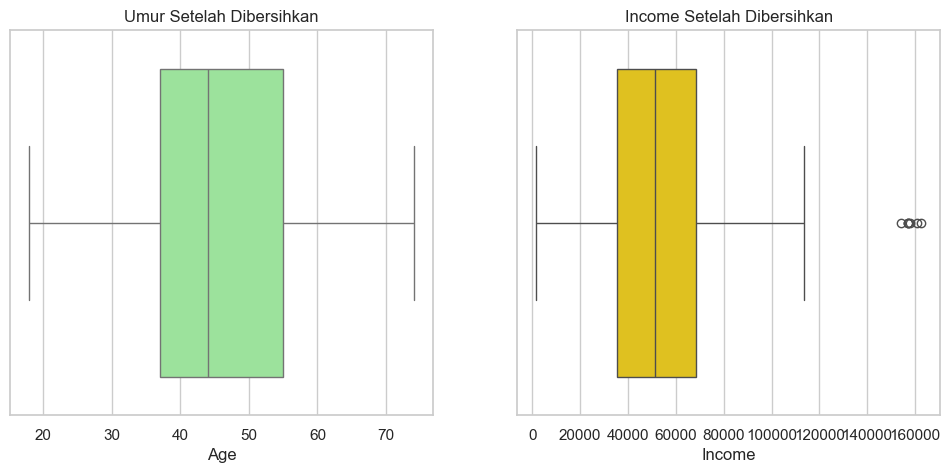

In [ ]:
#Verifikasi (Cek Ulang Boxplot)
plt.figure(figsize=(12, 5))

# Cek Boxplot Umur setelah dibersihkan
plt.subplot(1, 2, 1)
sns.boxplot(x=df_clean['Age'], color='lightgreen')
plt.title('Umur Setelah Dibersihkan')

# Cek Boxplot Income setelah dibersihkan
plt.subplot(1, 2, 2)
sns.boxplot(x=df_clean['Income'], color='gold')
plt.title('Income Setelah Dibersihkan')

plt.show()

In [22]:
# 1. Tentukan kolom apa saja yang mau dijumlahkan
kategori_produk = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']

# 2. Buat kolom 'Total_Spent' di dalam df_clean
df_clean['Total_Spent'] = df_clean[kategori_produk].sum(axis=1)

# Cek 5 data teratas untuk memastikan kolomnya muncul di paling kanan
display(df_clean[['Total_Spent']].head())

,Total_Spent
0,1190
1,577
2,251
3,11
4,91


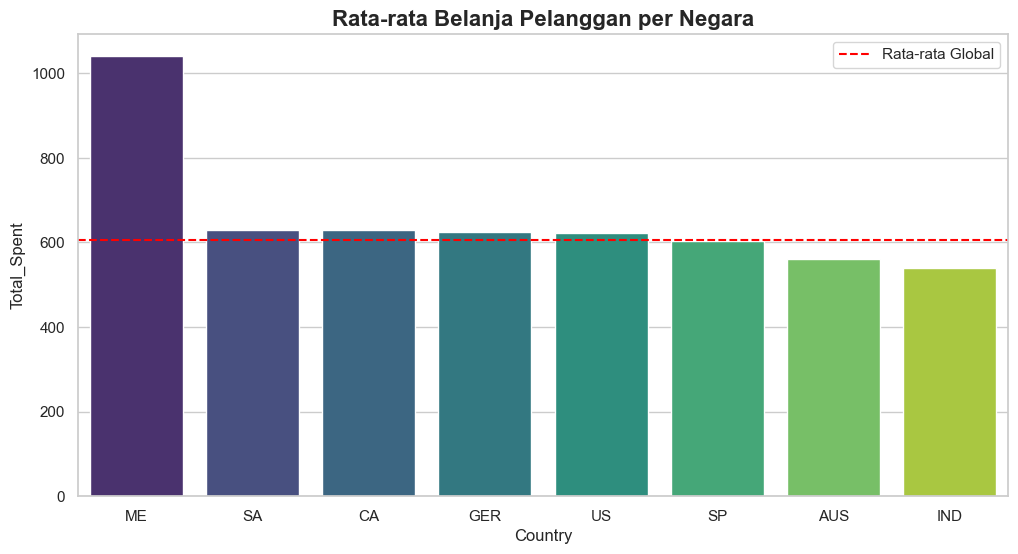

,Country,Total_Spent
0,ME,1040.666667
1,SA,629.811940
2,CA,628.850746
3,GER,624.275000
4,US,622.770642
5,SP,603.626143
6,AUS,561.018750
7,IND,540.272109


In [23]:
# Menghitung rata-rata pengeluaran per Negara
report_negara = df_clean.groupby('Country')['Total_Spent'].mean().sort_values(ascending=False).reset_index()

# Visualisasi
plt.figure(figsize=(12, 6))
sns.barplot(data=report_negara, x='Country', y='Total_Spent', palette='viridis')

plt.title('Rata-rata Belanja Pelanggan per Negara', fontsize=16, fontweight='bold')
plt.axhline(df_clean['Total_Spent'].mean(), color='red', linestyle='--', label='Rata-rata Global')
plt.legend()
plt.show()

display(report_negara)

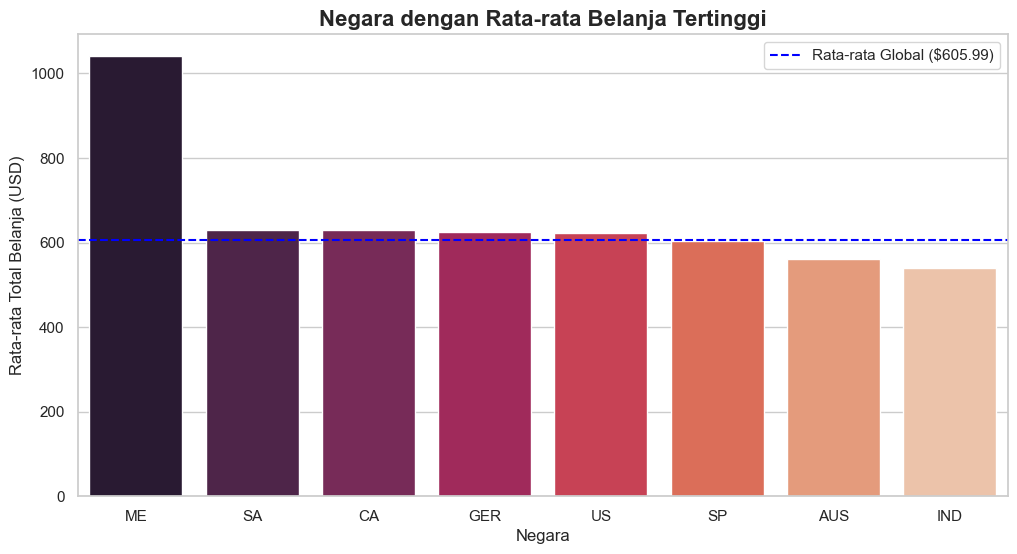

Tabel Peringkat Daya Beli per Negara:


,Country,Total_Spent
0,ME,1040.666667
1,SA,629.811940
2,CA,628.850746
3,GER,624.275000
4,US,622.770642
5,SP,603.626143
6,AUS,561.018750
7,IND,540.272109


In [24]:
# 1. Menghitung rata-rata pengeluaran per Negara
report_negara = df_clean.groupby('Country')['Total_Spent'].mean().sort_values(ascending=False).reset_index()

# 2. Visualisasi Negara dengan Daya Beli Tertinggi
plt.figure(figsize=(12, 6))
sns.barplot(data=report_negara, x='Country', y='Total_Spent', palette='rocket')

# Tambahkan garis rata-rata global sebagai patokan
rata_rata_global = df_clean['Total_Spent'].mean()
plt.axhline(rata_rata_global, color='blue', linestyle='--', label=f'Rata-rata Global (${rata_rata_global:.2f})')

plt.title('Negara dengan Rata-rata Belanja Tertinggi', fontsize=16, fontweight='bold')
plt.xlabel('Negara', fontsize=12)
plt.ylabel('Rata-rata Total Belanja (USD)', fontsize=12)
plt.legend()
plt.show()

# Menampilkan tabelnya
print("Tabel Peringkat Daya Beli per Negara:")
display(report_negara)

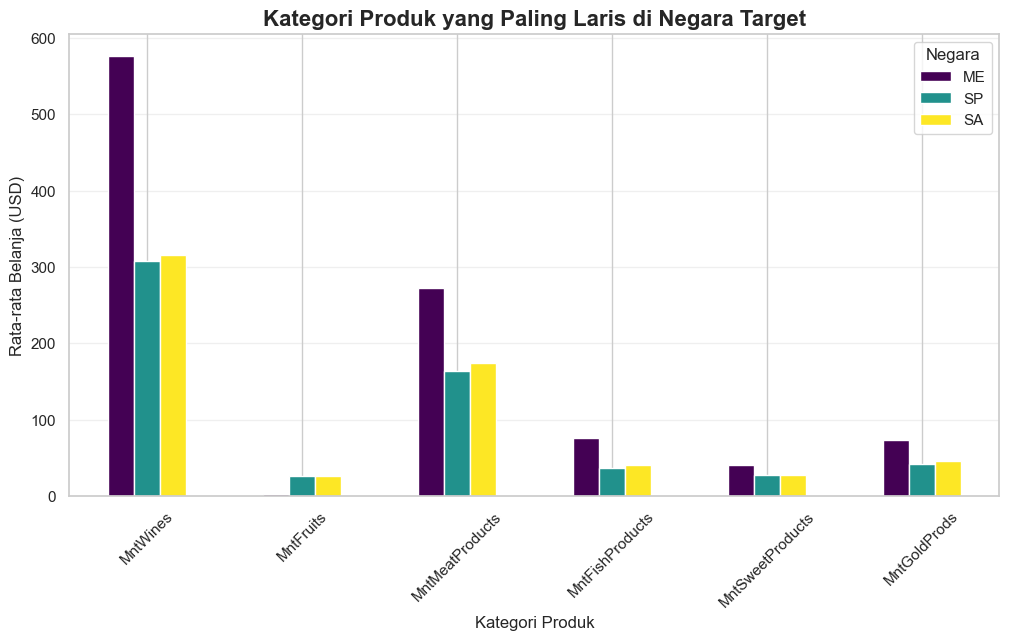

In [25]:
# 1. Menyiapkan data kategori produk
categories = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']

# 2. Mengambil rata-rata belanja per kategori untuk tiap negara
category_by_country = df_clean.groupby('Country')[categories].mean()

# 3. Visualisasi untuk 3 Negara Top (ME, SP, SA)
top_countries = ['ME', 'SP', 'SA']
category_by_country.loc[top_countries].T.plot(kind='bar', figsize=(12, 6), colormap='viridis')

plt.title('Kategori Produk yang Paling Laris di Negara Target', fontsize=16, fontweight='bold')
plt.ylabel('Rata-rata Belanja (USD)')
plt.xlabel('Kategori Produk')
plt.xticks(rotation=45)
plt.legend(title='Negara')
plt.grid(axis='y', alpha=0.3)
plt.show()

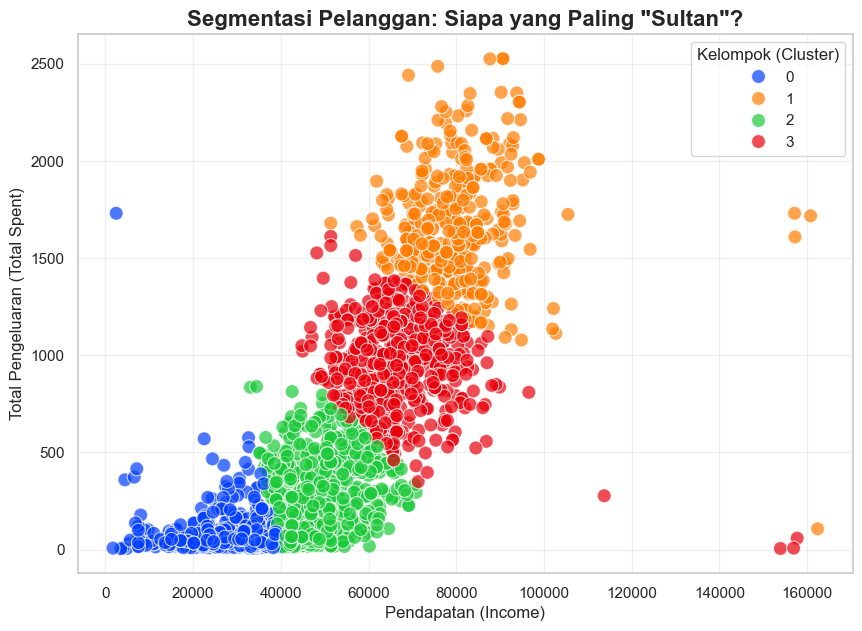

In [ ]:
# 1. Memilih fitur untuk dikelompokkan (Gaji vs Total Belanja)
X = df_clean[['Income', 'Total_Spent']]

# 2. Scaling (Menyamakan skala angka)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Menjalankan (K-Means) - Kita minta bagi jadi 4 kelompok
kmeans = KMeans(n_clusters=4, random_state=42)
df_clean['Segment'] = kmeans.fit_predict(X_scaled)

# 4. Visualisasi Hasil Segmentasi
plt.figure(figsize=(10, 7))
sns.scatterplot(data=df_clean, x='Income', y='Total_Spent', hue='Segment', palette='bright', s=100, alpha=0.7)

plt.title('Segmentasi Pelanggan: Siapa yang Paling "Sultan"?', fontsize=16, fontweight='bold')
plt.xlabel('Pendapatan (Income)', fontsize=12)
plt.ylabel('Total Pengeluaran (Total Spent)', fontsize=12)
plt.legend(title='Kelompok (Cluster)')
plt.grid(True, alpha=0.3)
plt.show()



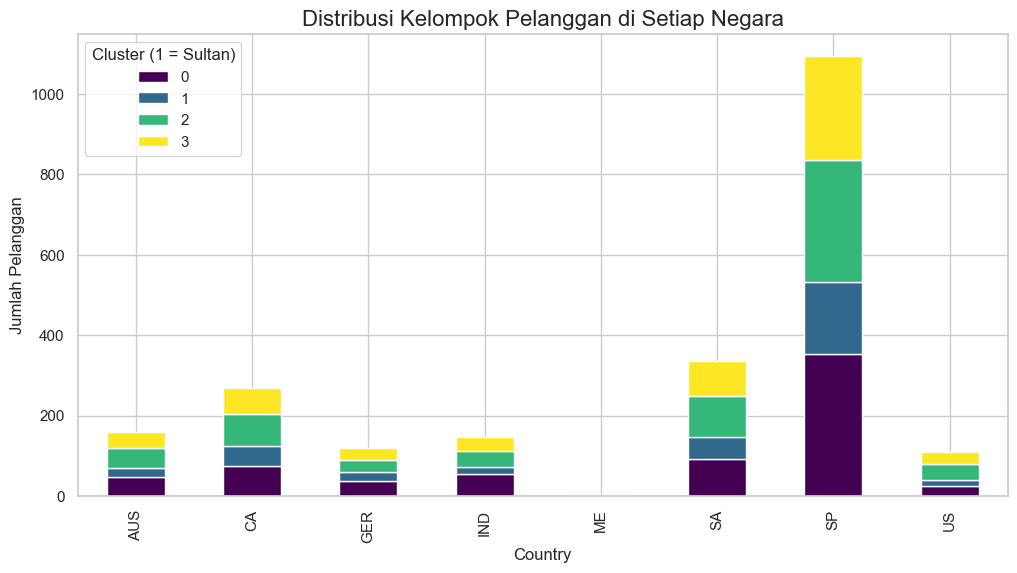

Profil Rata-rata per Kelompok:


,Age,Income,Total_Spent
Segment,,,
0,40.679356,27498.499268,76.358712
1,45.688889,80063.473611,1652.616667
2,47.072981,49129.753882,286.732919
3,47.907104,67253.475410,953.069217


In [28]:
# 1. Melihat distribusi Cluster per Negara
segment_market = pd.crosstab(df_clean['Country'], df_clean['Segment'])

# 2. Visualisasi
segment_market.plot(kind='bar', stacked=True, figsize=(12,6), colormap='viridis')
plt.title('Distribusi Kelompok Pelanggan di Setiap Negara', fontsize=16)
plt.ylabel('Jumlah Pelanggan')
plt.legend(title='Cluster (1 = Sultan)')
plt.show()

# 3. Hitung rata-rata profil per cluster
print("Profil Rata-rata per Kelompok:")
display(df_clean.groupby('Segment')[['Age', 'Income', 'Total_Spent']].mean())

In [29]:
# Menyimpan hasil data yang sudah bersih dan sudah ada label clusternya
df_clean.to_excel('Hasil_Analisis_Marketing_Final.xlsx', index=False)

print("✅ File 'Hasil_Analisis_Marketing_Final.xlsx' telah berhasil dibuat!")
print("Siap dikirim ke atasan sebagai bukti analisis data-driven.")

✅ File 'Hasil_Analisis_Marketing_Final.xlsx' telah berhasil dibuat!
Siap dikirim ke atasan sebagai bukti analisis data-driven.


In [30]:
# 1. Pastikan kolom segmentasi kita beri nama yang jelas
df_clean['Customer_Profile'] = df_clean['Segment'].map({
    1: 'Sultan (High Income, High Spent)',
    3: 'Potential Star (Medium)',
    0: 'Value Seeker A',
    2: 'Value Seeker B'
})

# 2. Ekspor ke CSV (Pilih CSV agar lebih ringan saat di-upload ke Looker)
df_clean.to_csv('marketing_data_for_looker.csv', index=False)

print("✅ File 'marketing_data_for_looker.csv' siap! Silakan download file ini.")

✅ File 'marketing_data_for_looker.csv' siap! Silakan download file ini.
